RANDOM FOREST

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import pickle
import warnings
import os
import sys

sys.path.append(os.path.abspath(".."))
warnings.filterwarnings('ignore')

df = pd.read_csv('../processed/dataset_final_cleaned.csv')
print(f"Dataset chargé : {len(df):,} lignes × {len(df.columns)} colonnes")

exclude_cols = ['traffic_volume', 'date_time', 'temp']

X = df.drop(columns=[col for col in exclude_cols if col in df.columns])
y = df['traffic_volume']

print(f"\nFeatures (X) : {X.shape}")
print(f"Target (y)   : {y.shape}")
print(f"\nNombre de features : {X.shape[1]}")
print(f"  Exemples : {list(X.columns[:5])}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set : {X_train.shape[0]:,} lignes ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(df)*100:.1f}%)")

print("\nHyperparamètres du modèle :")
print(f"   - n_estimators      : 100")
print(f"   - max_depth         : 20")
print(f"   - min_samples_split : 5")
print(f"   - min_samples_leaf  : 2")

print("\n Entraînement en cours:")
start_time = time.time()

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

training_time = time.time() - start_time

print(f"Entraînement terminé en {training_time:.2f} secondes")

print("\nRÉSULTATS - Random Forest :")
print(f"   RMSE (Root Mean Squared Error) : {rmse_rf:,.2f} véh/h")
print(f"   MAE  (Mean Absolute Error)     : {mae_rf:,.2f} véh/h")
print(f"   R²   (Coefficient de déterm.)  : {r2_rf:.4f} ({r2_rf*100:.2f}%)")
print(f"   Temps d'entraînement           : {training_time:.2f}s")

print("ANALYSE OVERFITTING")

y_train_pred = rf_model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

print("\nPerformances sur TRAIN :")
print(f"   - R²   : {r2_train:.4f}")
print(f"   - RMSE : {rmse_train:.2f} véh/h")
print(f"   - MAE  : {mae_train:.2f} véh/h")

print("\nPerformances sur TEST :")
print(f"   - R²   : {r2_rf:.4f}")
print(f"   - RMSE : {rmse_rf:.2f} véh/h")
print(f"   - MAE  : {mae_rf:.2f} véh/h")

# Vérifier l'overfitting
diff_r2 = r2_train - r2_rf
print(f"\nDifférence R² (Train - Test) : {diff_r2:.4f}")

if diff_r2 < 0.05:
    print("   Pas d'overfitting détecté")
elif diff_r2 < 0.1:
    print("   Léger overfitting")
else:
    print("   Overfitting détecté")


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 features les plus importantes :\n")
print(feature_importance.head(20).to_string(index=False))



Dataset chargé : 48,176 lignes × 90 colonnes

Features (X) : (48176, 87)
Target (y)   : (48176,)

Nombre de features : 87
  Exemples : ['rain_1h', 'snow_1h', 'clouds_all', 'temp_celsius', 'year']
Training set : 38,540 lignes (80.0%)
Test set     : 9,636 lignes (20.0%)

Hyperparamètres du modèle :
   - n_estimators      : 100
   - max_depth         : 20
   - min_samples_split : 5
   - min_samples_leaf  : 2

 Entraînement en cours:
Entraînement terminé en 8.57 secondes

RÉSULTATS - Random Forest :
   RMSE (Root Mean Squared Error) : 324.90 véh/h
   MAE  (Mean Absolute Error)     : 185.28 véh/h
   R²   (Coefficient de déterm.)  : 0.9732 (97.32%)
   Temps d'entraînement           : 8.57s
ANALYSE OVERFITTING

Performances sur TRAIN :
   - R²   : 0.9916
   - RMSE : 181.77 véh/h
   - MAE  : 102.60 véh/h

Performances sur TEST :
   - R²   : 0.9732
   - RMSE : 324.90 véh/h
   - MAE  : 185.28 véh/h

Différence R² (Train - Test) : 0.0184
   Pas d'overfitting détecté
Top 20 features les plus impor

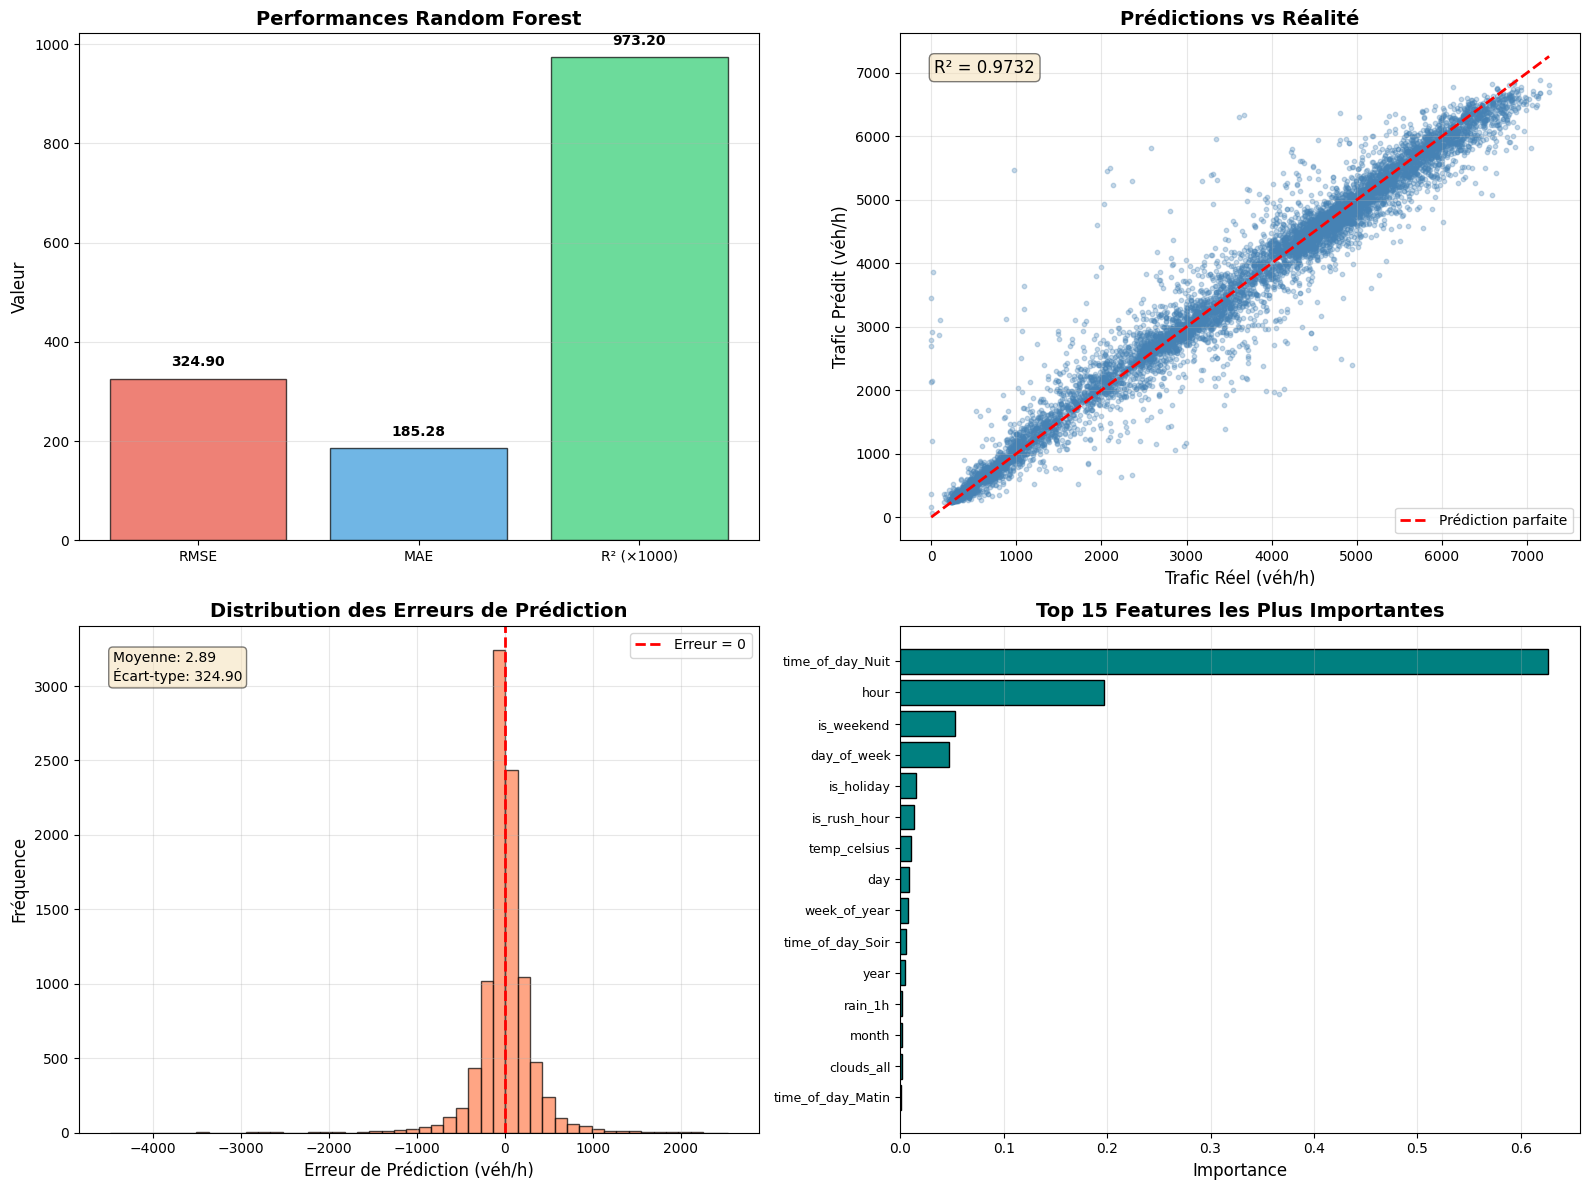

In [4]:
import os
import pickle
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1 : Métriques du modèle
metrics_names = ['RMSE', 'MAE', 'R² (×1000)']
metrics_values = [rmse_rf, mae_rf, r2_rf * 1000]
colors = ['#e74c3c', '#3498db', '#2ecc71']

axes[0, 0].bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Valeur', fontsize=12)
axes[0, 0].set_title('Performances Random Forest', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(metrics_values):
    axes[0, 0].text(i, v + max(metrics_values)*0.02, f'{v:.2f}', 
                    ha='center', va='bottom', fontweight='bold')

# Graphique 2 : Prédictions vs Réalité
axes[0, 1].scatter(y_test, y_pred_rf, alpha=0.3, s=10, color='steelblue')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Prédiction parfaite')
axes[0, 1].set_xlabel('Trafic Réel (véh/h)', fontsize=12)
axes[0, 1].set_ylabel('Trafic Prédit (véh/h)', fontsize=12)
axes[0, 1].set_title('Prédictions vs Réalité', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Ajouter R² sur le graphique
axes[0, 1].text(0.05, 0.95, f'R² = {r2_rf:.4f}', 
                transform=axes[0, 1].transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Graphique 3 : Distribution des erreurs
errors = y_test - y_pred_rf

axes[1, 0].hist(errors, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
axes[1, 0].set_xlabel('Erreur de Prédiction (véh/h)', fontsize=12)
axes[1, 0].set_ylabel('Fréquence', fontsize=12)
axes[1, 0].set_title('Distribution des Erreurs de Prédiction', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Statistiques des erreurs
mean_error = errors.mean()
std_error = errors.std()
axes[1, 0].text(0.05, 0.95, f'Moyenne: {mean_error:.2f}\nÉcart-type: {std_error:.2f}', 
                transform=axes[1, 0].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Graphique 4 : Top 15 Features Importance
top_15 = feature_importance.head(15).sort_values('Importance')

axes[1, 1].barh(range(len(top_15)), top_15['Importance'], color='teal', edgecolor='black')
axes[1, 1].set_yticks(range(len(top_15)))
axes[1, 1].set_yticklabels(top_15['Feature'], fontsize=9)
axes[1, 1].set_xlabel('Importance', fontsize=12)
axes[1, 1].set_title('Top 15 Features les Plus Importantes', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


models_dir = os.path.abspath("../models")
os.makedirs(models_dir, exist_ok=True)
model_filename = os.path.join(models_dir, "random_forest_model.pkl")

with open(model_filename, "wb") as f:
    pickle.dump(rf_model, f)


results = {
    "model_name": "Random Forest",
    "rmse": rmse_rf,
    "mae": mae_rf,
    "r2": r2_rf,
    "training_time": training_time,
    "features": list(X.columns),
    "feature_importance": feature_importance.to_dict(),
    "hyperparameters": {
        "n_estimators": rf_model.n_estimators,
        "max_depth": rf_model.max_depth,
        "min_samples_split": rf_model.min_samples_split,
        "min_samples_leaf": rf_model.min_samples_leaf,
    },
    "overfitting_analysis": {
        "r2_train": r2_train,
        "r2_test": r2_rf,
        "diff_r2": diff_r2,
    },
}

results_filename = os.path.join(models_dir, "random_forest_results.pkl")

with open(results_filename, "wb") as f:
    pickle.dump(results, f)



Rapport Random Forest

In [5]:
print(f"""
MODÈLE : Random Forest Regressor

 HYPERPARAMÈTRES :
   - n_estimators      : {rf_model.n_estimators}
   - max_depth         : {rf_model.max_depth}
   - min_samples_split : {rf_model.min_samples_split}
   - min_samples_leaf  : {rf_model.min_samples_leaf}

 PERFORMANCES :
   - RMSE : {rmse_rf:,.2f} véh/h
   - MAE  : {mae_rf:,.2f} véh/h
   - R²   : {r2_rf:.4f} ({r2_rf*100:.2f}%)

 TEMPS D'ENTRAÎNEMENT :
   - {training_time:.2f} secondes

 TOP 3 FEATURES :
   1. {feature_importance.iloc[0]['Feature']} ({feature_importance.iloc[0]['Importance']:.4f})
   2. {feature_importance.iloc[1]['Feature']} ({feature_importance.iloc[1]['Importance']:.4f})
   3. {feature_importance.iloc[2]['Feature']} ({feature_importance.iloc[2]['Importance']:.4f})

 FICHIERS GÉNÉRÉS :
   - {model_filename}
   - {results_filename}
   - random_forest_results.png
""")




MODÈLE : Random Forest Regressor

 HYPERPARAMÈTRES :
   - n_estimators      : 100
   - max_depth         : 20
   - min_samples_split : 5
   - min_samples_leaf  : 2

 PERFORMANCES :
   - RMSE : 324.90 véh/h
   - MAE  : 185.28 véh/h
   - R²   : 0.9732 (97.32%)

 TEMPS D'ENTRAÎNEMENT :
   - 8.57 secondes

 TOP 3 FEATURES :
   1. time_of_day_Nuit (0.6260)
   2. hour (0.1972)
   3. is_weekend (0.0533)

 FICHIERS GÉNÉRÉS :
   - c:\Users\dell\Downloads\SDBDIA 3\traffic-prediction-project\traffic-prediction-project\models\random_forest_model.pkl
   - c:\Users\dell\Downloads\SDBDIA 3\traffic-prediction-project\traffic-prediction-project\models\random_forest_results.pkl
   - random_forest_results.png



XGBOOST BASELINE

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import time
import pickle
import warnings
warnings.filterwarnings('ignore')


exclude_cols = ['traffic_volume', 'date_time', 'temp']

X = df.drop(columns=[col for col in exclude_cols if col in df.columns])
y = df['traffic_volume']

print(f"\nFeatures (X) : {X.shape}")
print(f"Target (y)   : {y.shape}")
print(f"\nNombre de features : {X.shape[1]}")
print(f"   Exemples : {list(X.columns[:5])}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set : {X_train.shape[0]:,} lignes ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(df)*100:.1f}%)")

print("\n Entraînement en cours:")
start_time = time.time()

xgb_baseline = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_baseline.fit(X_train, y_train)

y_pred_baseline = xgb_baseline.predict(X_test)

rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

training_time = time.time() - start_time

print(f"Entraînement terminé en {training_time:.2f} secondes")

print("\nRÉSULTATS - XGBoost BASELINE :")
print(f"   RMSE (Root Mean Squared Error) : {rmse_baseline:,.2f} véh/h")
print(f"   MAE  (Mean Absolute Error)     : {mae_baseline:,.2f} véh/h")
print(f"   R²   (Coefficient de déterm.)  : {r2_baseline:.4f} ({r2_baseline*100:.2f}%)")
print(f"   Temps d'entraînement           : {training_time:.2f}s")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 features les plus importantes :\n")
print(feature_importance.head(20).to_string(index=False))



Features (X) : (48176, 87)
Target (y)   : (48176,)

Nombre de features : 87
   Exemples : ['rain_1h', 'snow_1h', 'clouds_all', 'temp_celsius', 'year']
Training set : 38,540 lignes (80.0%)
Test set     : 9,636 lignes (20.0%)

 Entraînement en cours:
Entraînement terminé en 0.71 secondes

RÉSULTATS - XGBoost BASELINE :
   RMSE (Root Mean Squared Error) : 299.66 véh/h
   MAE  (Mean Absolute Error)     : 188.26 véh/h
   R²   (Coefficient de déterm.)  : 0.9772 (97.72%)
   Temps d'entraînement           : 0.71s

Top 20 features les plus importantes :

                       Feature  Importance
              time_of_day_Nuit    0.899656
                          hour    0.023204
                   day_of_week    0.016689
                    is_holiday    0.016415
                  is_rush_hour    0.008995
                  season_Hiver    0.008129
         temp_level_Très Froid    0.003384
           weather_main_Clouds    0.001921
weather_description_heavy snow    0.001770
              wea

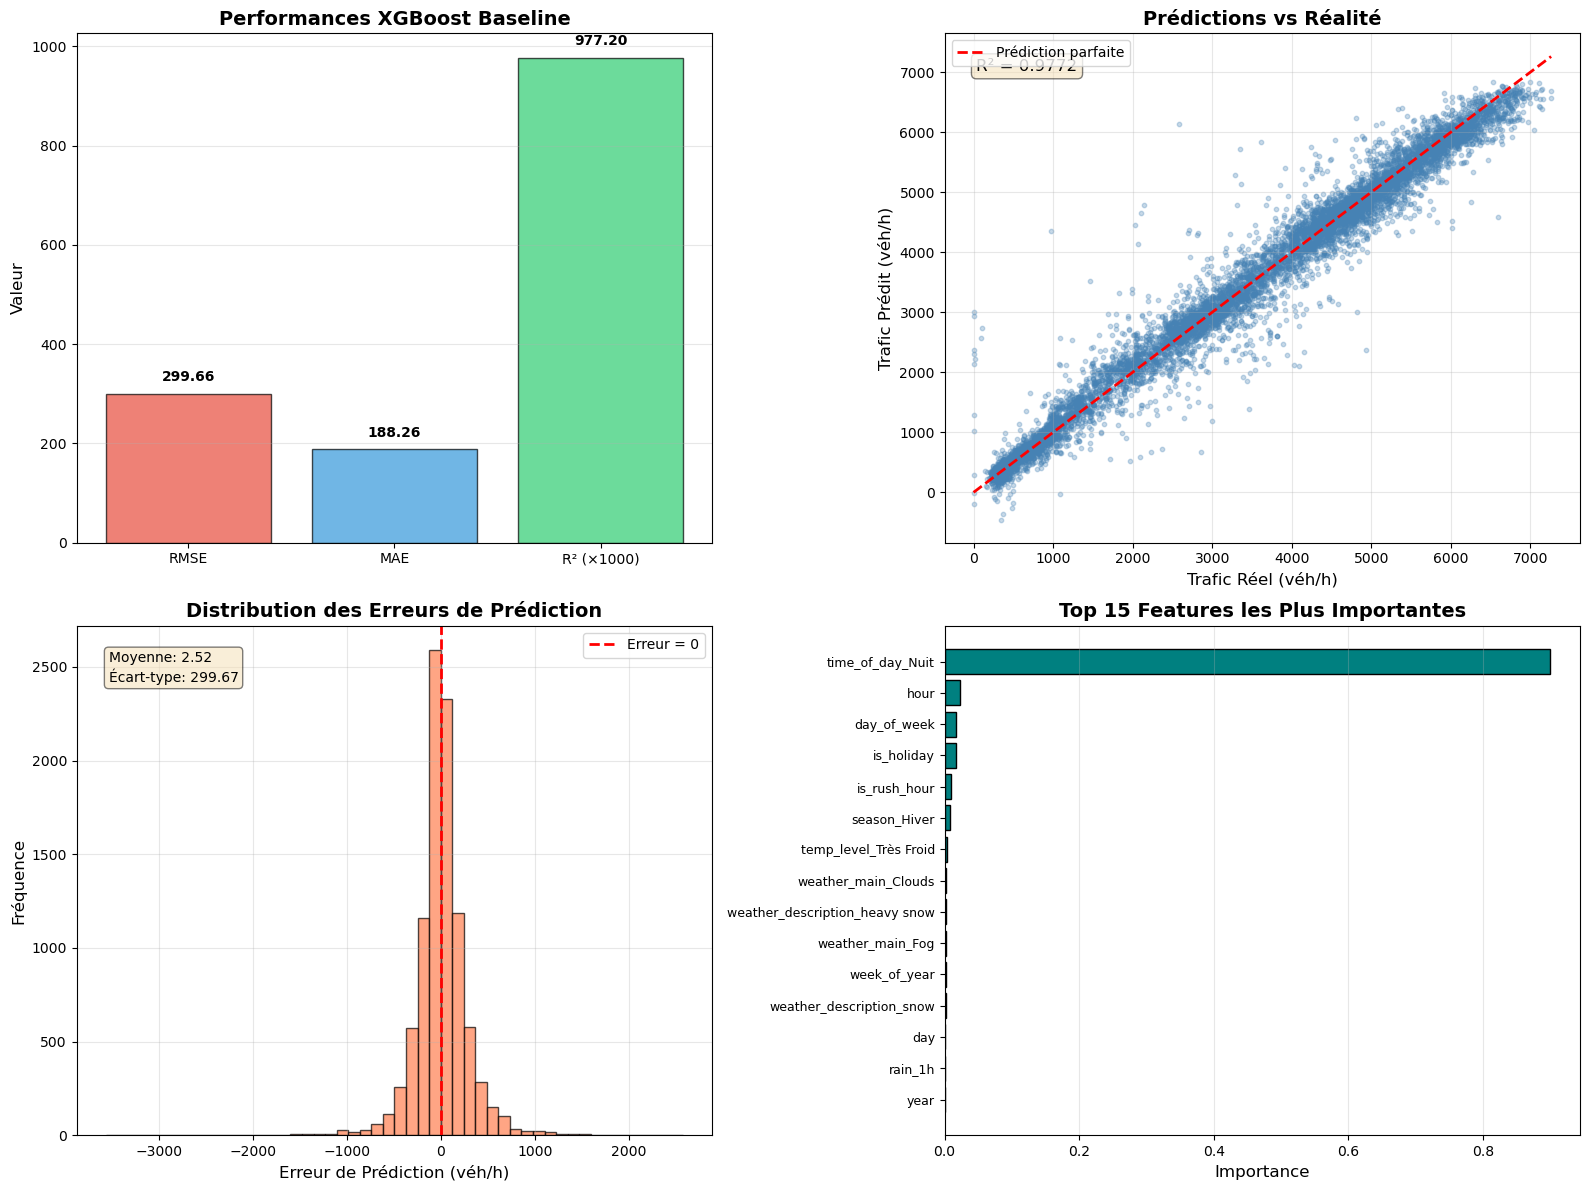

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1 : Métriques du modèle
metrics_names = ['RMSE', 'MAE', 'R² (×1000)']
metrics_values = [rmse_baseline, mae_baseline, r2_baseline * 1000]
colors = ['#e74c3c', '#3498db', '#2ecc71']

axes[0, 0].bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Valeur', fontsize=12)
axes[0, 0].set_title('Performances XGBoost Baseline', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(metrics_values):
    axes[0, 0].text(i, v + max(metrics_values)*0.02, f'{v:.2f}', 
                    ha='center', va='bottom', fontweight='bold')

# Graphique 2 : Prédictions vs Réalité
axes[0, 1].scatter(y_test, y_pred_baseline, alpha=0.3, s=10, color='steelblue')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Prédiction parfaite')
axes[0, 1].set_xlabel('Trafic Réel (véh/h)', fontsize=12)
axes[0, 1].set_ylabel('Trafic Prédit (véh/h)', fontsize=12)
axes[0, 1].set_title('Prédictions vs Réalité', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Ajouter R² sur le graphique
axes[0, 1].text(0.05, 0.95, f'R² = {r2_baseline:.4f}', 
                transform=axes[0, 1].transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Graphique 3 : Distribution des erreurs
errors = y_test - y_pred_baseline

axes[1, 0].hist(errors, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
axes[1, 0].set_xlabel('Erreur de Prédiction (véh/h)', fontsize=12)
axes[1, 0].set_ylabel('Fréquence', fontsize=12)
axes[1, 0].set_title('Distribution des Erreurs de Prédiction', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Statistiques des erreurs
mean_error = errors.mean()
std_error = errors.std()
axes[1, 0].text(0.05, 0.95, f'Moyenne: {mean_error:.2f}\nÉcart-type: {std_error:.2f}', 
                transform=axes[1, 0].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Graphique 4 : Top 15 Features Importance
top_15 = feature_importance.head(15).sort_values('Importance')

axes[1, 1].barh(range(len(top_15)), top_15['Importance'], color='teal', edgecolor='black')
axes[1, 1].set_yticks(range(len(top_15)))
axes[1, 1].set_yticklabels(top_15['Feature'], fontsize=9)
axes[1, 1].set_xlabel('Importance', fontsize=12)
axes[1, 1].set_title('Top 15 Features les Plus Importantes', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

models_dir = os.path.abspath("../models")
os.makedirs(models_dir, exist_ok=True)

model_filename = os.path.join(models_dir, "xgboost_baseline_model.pkl")

with open(model_filename, "wb") as f:
    pickle.dump(xgb_baseline, f)

results = {
    "model_name": "XGBoost Baseline",
    "rmse": rmse_baseline,
    "mae": mae_baseline,
    "r2": r2_baseline,
    "training_time": training_time,
    "features": list(X.columns),
    "feature_importance": feature_importance.to_dict(),
    "default_params": {
        "random_state": 42,
        "n_jobs": -1,
    },
}

results_filename = os.path.join(models_dir, "xgboost_baseline_results.pkl")

with open(results_filename, "wb") as f:
    pickle.dump(results, f)

In [ ]:
print(f"""
 MODÈLE : XGBoost Baseline (Paramètres par défaut)

 PERFORMANCES :
   • RMSE : {rmse_baseline:,.2f} véh/h
   • MAE  : {mae_baseline:,.2f} véh/h
   • R²   : {r2_baseline:.4f} ({r2_baseline*100:.2f}%)

 TEMPS D'ENTRAÎNEMENT :
   • {training_time:.2f} secondes

 TOP 3 FEATURES :
   1. {feature_importance.iloc[0]['Feature']} ({feature_importance.iloc[0]['Importance']:.4f})
   2. {feature_importance.iloc[1]['Feature']} ({feature_importance.iloc[1]['Importance']:.4f})
   3. {feature_importance.iloc[2]['Feature']} ({feature_importance.iloc[2]['Importance']:.4f})

""")



 MODÈLE : XGBoost Baseline (Paramètres par défaut)

 PERFORMANCES :
   • RMSE : 299.66 véh/h
   • MAE  : 188.26 véh/h
   • R²   : 0.9772 (97.72%)

 TEMPS D'ENTRAÎNEMENT :
   • 1.43 secondes

 TOP 3 FEATURES :
   1. time_of_day_Nuit (0.8997)
   2. hour (0.0232)
   3. day_of_week (0.0167)




XGBOOST OPTIMISE

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

exclude_cols = ['traffic_volume', 'date_time', 'temp']

X = df.drop(columns=[col for col in exclude_cols if col in df.columns])
y = df['traffic_volume']

print(f"\nFeatures (X) : {X.shape}")
print(f"Target (y)   : {y.shape}")
print(f"\nNombre de features : {X.shape[1]}")
print(f"   Exemples : {list(X.columns[:5])}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set : {X_train.shape[0]:,} lignes ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]:,} lignes ({X_test.shape[0]/len(df)*100:.1f}%)")

param_grid = {
    'n_estimators': [100, 200, 300],           # Nombre d'arbres
    'max_depth': [3, 5, 7],                    # Profondeur max
    'learning_rate': [0.01, 0.05, 0.1],        # Taux d'apprentissage
    'subsample': [0.8, 1.0],                   # Fraction des données
    'colsample_bytree': [0.8, 1.0]             # Fraction des features
}

print("\n Hyperparamètres à optimiser :")
print(f"   - n_estimators     : {param_grid['n_estimators']}")
print(f"   - max_depth        : {param_grid['max_depth']}")
print(f"   - learning_rate    : {param_grid['learning_rate']}")
print(f"   - subsample        : {param_grid['subsample']}")
print(f"   - colsample_bytree : {param_grid['colsample_bytree']}")

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal de combinaisons à tester : {total_combinations}")
print(f"   Avec validation croisée 3-fold : {total_combinations * 3} entraînements")

print("\nOptimisation avec GridSearchCV:")

start_time = time.time()

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid=param_grid,
    cv=3,                          # 3-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,                     # Utiliser tous les CPU
    verbose=1
)

grid_search.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"\nGridSearch terminé en {training_time:.2f} secondes ({training_time/60:.2f} minutes)")


print("\n")
for param, value in grid_search.best_params_.items():
    print(f"   • {param:20s} : {value}")

print(f"\nMeilleur score CV (MSE négatif) : {grid_search.best_score_:.2f}")

xgb_optimized = grid_search.best_estimator_

y_pred_optimized = xgb_optimized.predict(X_test)

rmse_optimized = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
mae_optimized = mean_absolute_error(y_test, y_pred_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)

print("\nRÉSULTATS - XGBoost OPTIMISÉ :")
print(f"   RMSE (Root Mean Squared Error) : {rmse_optimized:,.2f} véh/h")
print(f"   MAE  (Mean Absolute Error)     : {mae_optimized:,.2f} véh/h")
print(f"   R²   (Coefficient de déterm.)  : {r2_optimized:.4f} ({r2_optimized*100:.2f}%)")
print(f"   Temps d'entraînement total     : {training_time:.2f}s ({training_time/60:.2f} min)")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_optimized.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 features les plus importantes :\n")
print(feature_importance.head(20).to_string(index=False))

cv_results = pd.DataFrame(grid_search.cv_results_)

print("\nTOP 5 MEILLEURES COMBINAISONS :\n")
top_5 = cv_results.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

for idx, row in top_5.iterrows():
    print(f"Rang {int(row['rank_test_score'])}:")
    print(f"   Paramètres : {row['params']}")
    print(f"   Score CV   : {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print()



Features (X) : (48176, 87)
Target (y)   : (48176,)

Nombre de features : 87
   Exemples : ['rain_1h', 'snow_1h', 'clouds_all', 'temp_celsius', 'year']
Training set : 38,540 lignes (80.0%)
Test set     : 9,636 lignes (20.0%)

 Hyperparamètres à optimiser :
   - n_estimators     : [100, 200, 300]
   - max_depth        : [3, 5, 7]
   - learning_rate    : [0.01, 0.05, 0.1]
   - subsample        : [0.8, 1.0]
   - colsample_bytree : [0.8, 1.0]

Total de combinaisons à tester : 108
   Avec validation croisée 3-fold : 324 entraînements

Optimisation avec GridSearchCV:
Fitting 3 folds for each of 108 candidates, totalling 324 fits

GridSearch terminé en 150.44 secondes (2.51 minutes)


   • colsample_bytree     : 1.0
   • learning_rate        : 0.1
   • max_depth            : 7
   • n_estimators         : 300
   • subsample            : 0.8

Meilleur score CV (MSE négatif) : -76811.20

RÉSULTATS - XGBoost OPTIMISÉ :
   RMSE (Root Mean Squared Error) : 274.51 véh/h
   MAE  (Mean Absolute Error)


Graphiques sauvegardés : 'xgboost_optimized_results.png'


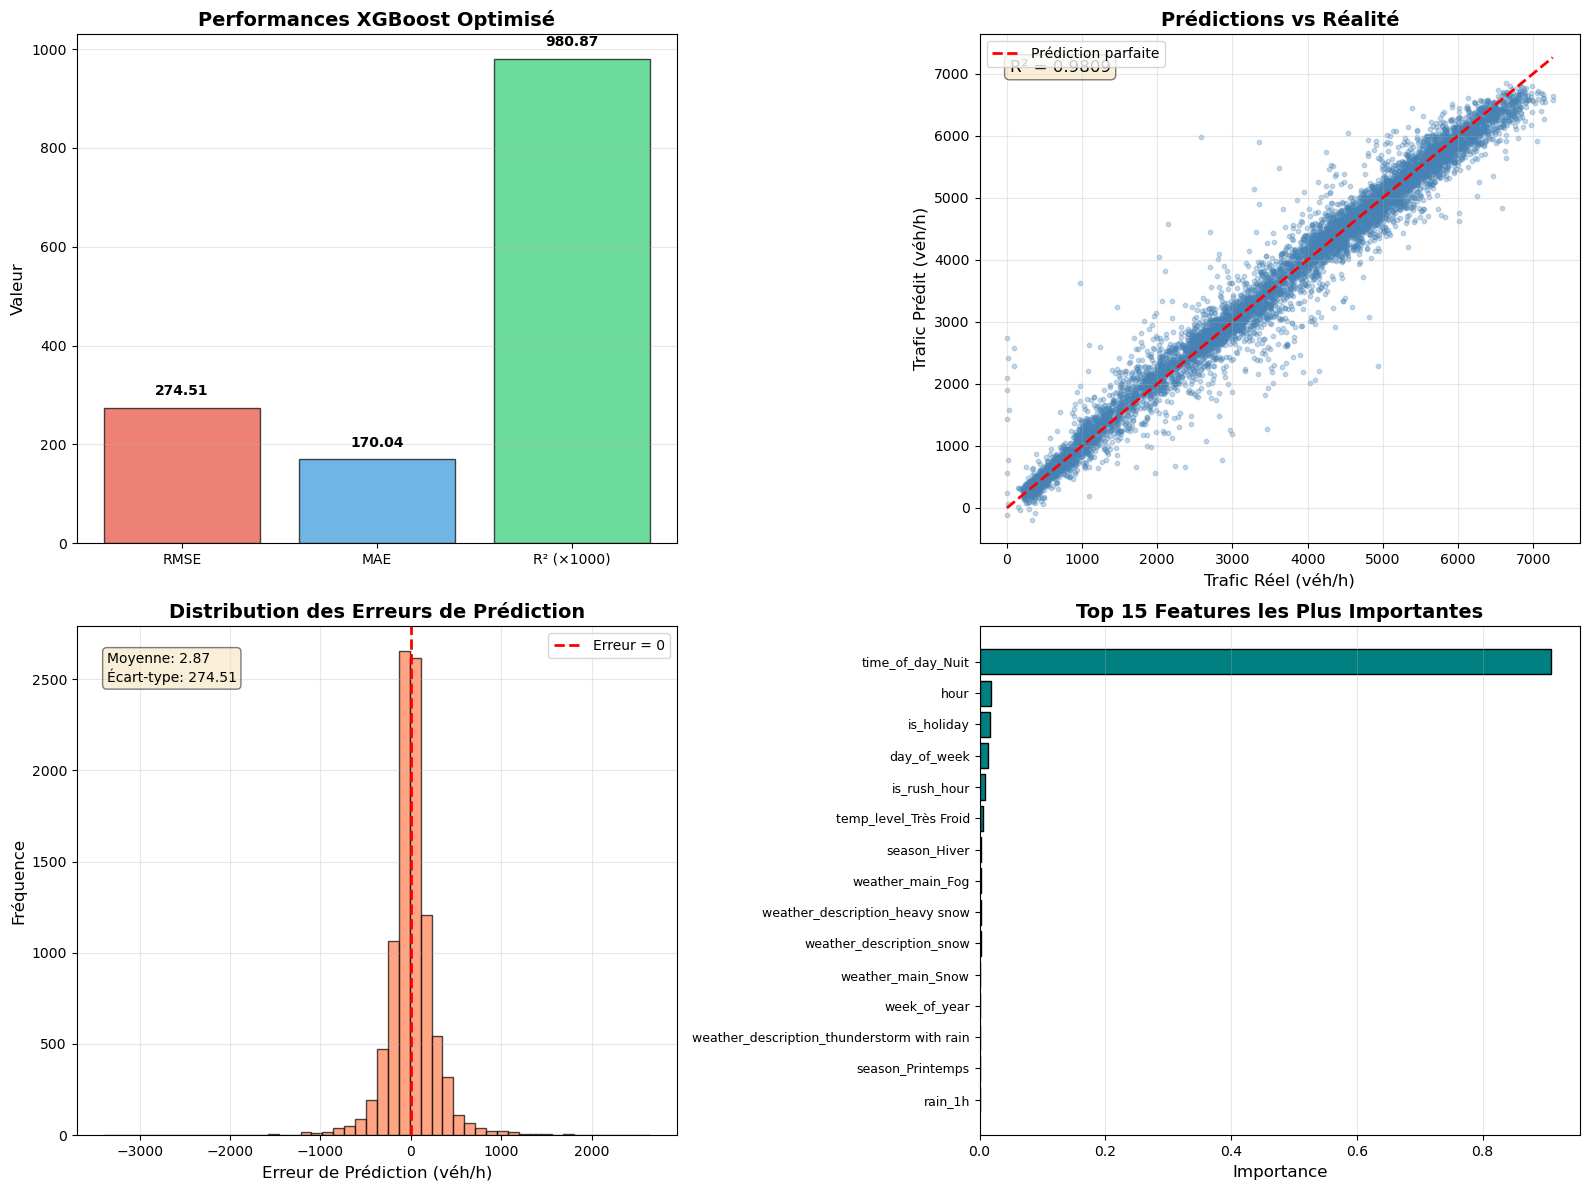

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1 : Métriques du modèle
metrics_names = ['RMSE', 'MAE', 'R² (×1000)']
metrics_values = [rmse_optimized, mae_optimized, r2_optimized * 1000]
colors = ['#e74c3c', '#3498db', '#2ecc71']

axes[0, 0].bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Valeur', fontsize=12)
axes[0, 0].set_title('Performances XGBoost Optimisé', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

for i, v in enumerate(metrics_values):
    axes[0, 0].text(i, v + max(metrics_values)*0.02, f'{v:.2f}', 
                    ha='center', va='bottom', fontweight='bold')

# Graphique 2 : Prédictions vs Réalité
axes[0, 1].scatter(y_test, y_pred_optimized, alpha=0.3, s=10, color='steelblue')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', lw=2, label='Prédiction parfaite')
axes[0, 1].set_xlabel('Trafic Réel (véh/h)', fontsize=12)
axes[0, 1].set_ylabel('Trafic Prédit (véh/h)', fontsize=12)
axes[0, 1].set_title('Prédictions vs Réalité', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Ajouter R² sur le graphique
axes[0, 1].text(0.05, 0.95, f'R² = {r2_optimized:.4f}', 
                transform=axes[0, 1].transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Graphique 3 : Distribution des erreurs
errors = y_test - y_pred_optimized

axes[1, 0].hist(errors, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Erreur = 0')
axes[1, 0].set_xlabel('Erreur de Prédiction (véh/h)', fontsize=12)
axes[1, 0].set_ylabel('Fréquence', fontsize=12)
axes[1, 0].set_title('Distribution des Erreurs de Prédiction', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Statistiques des erreurs
mean_error = errors.mean()
std_error = errors.std()
axes[1, 0].text(0.05, 0.95, f'Moyenne: {mean_error:.2f}\nÉcart-type: {std_error:.2f}', 
                transform=axes[1, 0].transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Graphique 4 : Top 15 Features Importance
top_15 = feature_importance.head(15).sort_values('Importance')

axes[1, 1].barh(range(len(top_15)), top_15['Importance'], color='teal', edgecolor='black')
axes[1, 1].set_yticks(range(len(top_15)))
axes[1, 1].set_yticklabels(top_15['Feature'], fontsize=9)
axes[1, 1].set_xlabel('Importance', fontsize=12)
axes[1, 1].set_title('Top 15 Features les Plus Importantes', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_optimized_results.png', dpi=150, bbox_inches='tight')
print("\nGraphiques sauvegardés : 'xgboost_optimized_results.png'")
plt.show()

models_dir = os.path.abspath("../models")
os.makedirs(models_dir, exist_ok=True)
model_filename = os.path.join(models_dir, "xgboost_optimized_model.pkl")

with open(model_filename, "wb") as f:
    pickle.dump(xgb_optimized, f)


results = {
    "model_name": "XGBoost Optimisé",
    "rmse": rmse_optimized,
    "mae": mae_optimized,
    "r2": r2_optimized,
    "training_time": training_time,
    "features": list(X.columns),
    "feature_importance": feature_importance.to_dict(),
    "best_params": grid_search.best_params_,
    "cv_best_score": grid_search.best_score_,
    "all_cv_results": cv_results.to_dict(),
}

results_filename = os.path.join(models_dir, "xgboost_optimized_results.pkl")

with open(results_filename, "wb") as f:
    pickle.dump(results, f)


In [ ]:
print(f"""
 MODÈLE : XGBoost Optimisé (GridSearchCV)

 PERFORMANCES :
   - RMSE : {rmse_optimized:,.2f} véh/h
   - MAE  : {mae_optimized:,.2f} véh/h
   - R²   : {r2_optimized:.4f} ({r2_optimized*100:.2f}%)

 TEMPS D'ENTRAÎNEMENT :
   - {training_time:.2f} secondes ({training_time/60:.2f} minutes)
   - {total_combinations * 3} modèles testés

 MEILLEURS HYPERPARAMÈTRES :
""")

for param, value in grid_search.best_params_.items():
    print(f"   - {param:20s} : {value}")

print(f"""
 TOP 3 FEATURES :
   1. {feature_importance.iloc[0]['Feature']} ({feature_importance.iloc[0]['Importance']:.4f})
   2. {feature_importance.iloc[1]['Feature']} ({feature_importance.iloc[1]['Importance']:.4f})
   3. {feature_importance.iloc[2]['Feature']} ({feature_importance.iloc[2]['Importance']:.4f})

""")



 MODÈLE : XGBoost Optimisé (GridSearchCV)

 PERFORMANCES :
   - RMSE : 274.51 véh/h
   - MAE  : 170.04 véh/h
   - R²   : 0.9809 (98.09%)

 TEMPS D'ENTRAÎNEMENT :
   - 150.44 secondes (2.51 minutes)
   - 324 modèles testés

 MEILLEURS HYPERPARAMÈTRES :

   - colsample_bytree     : 1.0
   - learning_rate        : 0.1
   - max_depth            : 7
   - n_estimators         : 300
   - subsample            : 0.8

 TOP 3 FEATURES :
   1. time_of_day_Nuit (0.9095)
   2. hour (0.0174)
   3. is_holiday (0.0169)




COMPARAISON

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Charger les résultats des 3 modèles
with open(os.path.join(models_dir, "xgboost_baseline_results.pkl"), "rb") as f:
    results_baseline = pickle.load(f)

with open(os.path.join(models_dir, "xgboost_optimized_results.pkl"), "rb") as f:
    results_optimized = pickle.load(f)

with open(os.path.join(models_dir, "random_forest_results.pkl"), "rb") as f:
    results_rf = pickle.load(f)

# Créer un DataFrame comparatif
comparison_df = pd.DataFrame([
    {
        'Modèle': 'XGBoost Baseline',
        'RMSE': results_baseline['rmse'],
        'MAE': results_baseline['mae'],
        'R²': results_baseline['r2'],
        'Temps (s)': results_baseline['training_time']
    },
    {
        'Modèle': 'XGBoost Optimisé',
        'RMSE': results_optimized['rmse'],
        'MAE': results_optimized['mae'],
        'R²': results_optimized['r2'],
        'Temps (s)': results_optimized['training_time']
    },
    {
        'Modèle': 'Random Forest',
        'RMSE': results_rf['rmse'],
        'MAE': results_rf['mae'],
        'R²': results_rf['r2'],
        'Temps (s)': results_rf['training_time']
    }
])

comparison_df


,Modèle,RMSE,MAE,R²,Temps (s)
0,XGBoost Baseline,299.661742,188.262297,0.977202,1.431092
1,XGBoost Optimisé,274.510122,170.043634,0.980868,150.442599
2,Random Forest,324.898231,185.279452,0.973200,1.431092


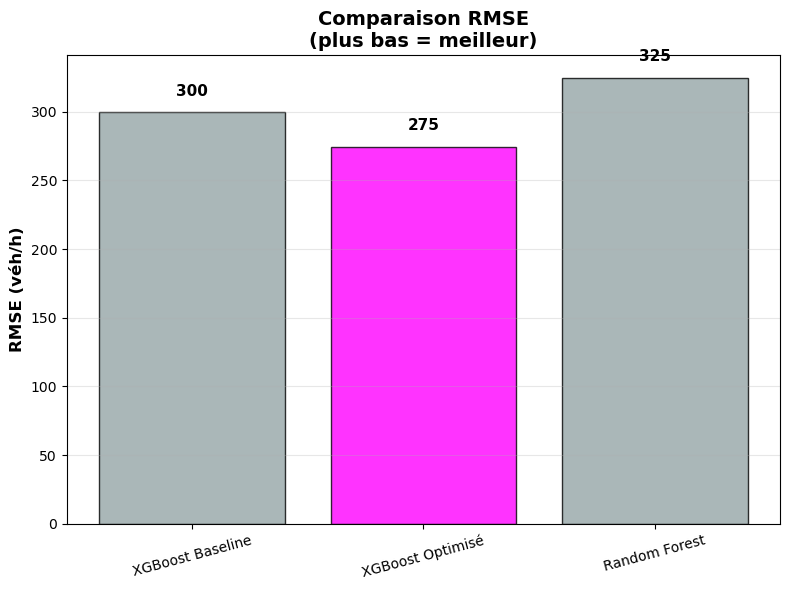

In [ ]:
plt.figure(figsize=(8, 6))

best_idx = comparison_df['RMSE'].idxmin()
colors = ["fuchsia" if i == best_idx else '#95a5a6' for i in range(len(comparison_df))]

plt.bar(comparison_df['Modèle'], comparison_df['RMSE'], color=colors, edgecolor='black', alpha=0.8)
plt.ylabel('RMSE (véh/h)', fontsize=12, fontweight='bold')
plt.title('Comparaison RMSE\n(plus bas = meilleur)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df['RMSE']):
    plt.text(i, v + 10, f'{v:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


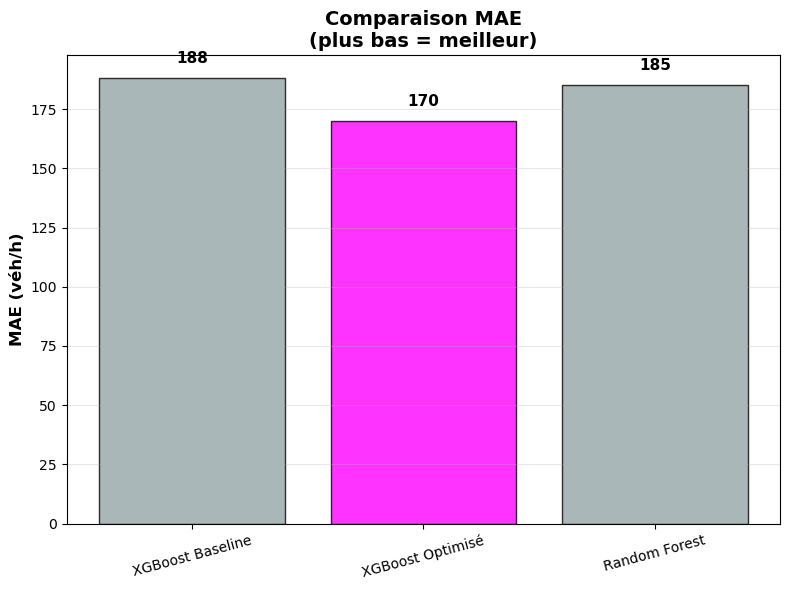

In [ ]:
plt.figure(figsize=(8, 6))

best_idx = comparison_df['MAE'].idxmin()
colors = ['fuchsia' if i == best_idx else '#95a5a6' for i in range(len(comparison_df))]

plt.bar(comparison_df['Modèle'], comparison_df['MAE'], color=colors, edgecolor='black', alpha=0.8)
plt.ylabel('MAE (véh/h)', fontsize=12, fontweight='bold')
plt.title('Comparaison MAE\n(plus bas = meilleur)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df['MAE']):
    plt.text(i, v + 5, f'{v:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

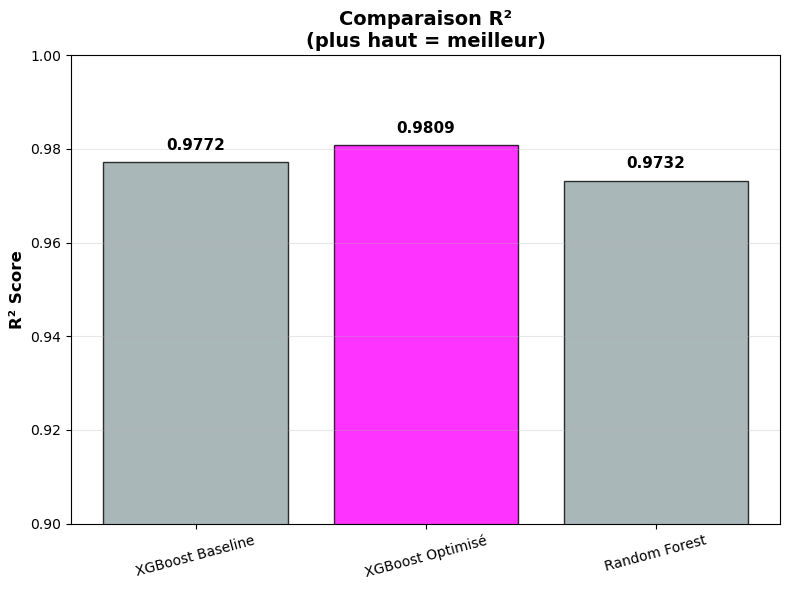

In [ ]:
plt.figure(figsize=(8, 6))

best_idx = comparison_df['R²'].idxmax()
colors = ['fuchsia' if i == best_idx else '#95a5a6' for i in range(len(comparison_df))]

plt.bar(comparison_df['Modèle'], comparison_df['R²'], color=colors, edgecolor='black', alpha=0.8)
plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.title('Comparaison R²\n(plus haut = meilleur)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0.9, 1.0) 

for i, v in enumerate(comparison_df['R²']):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


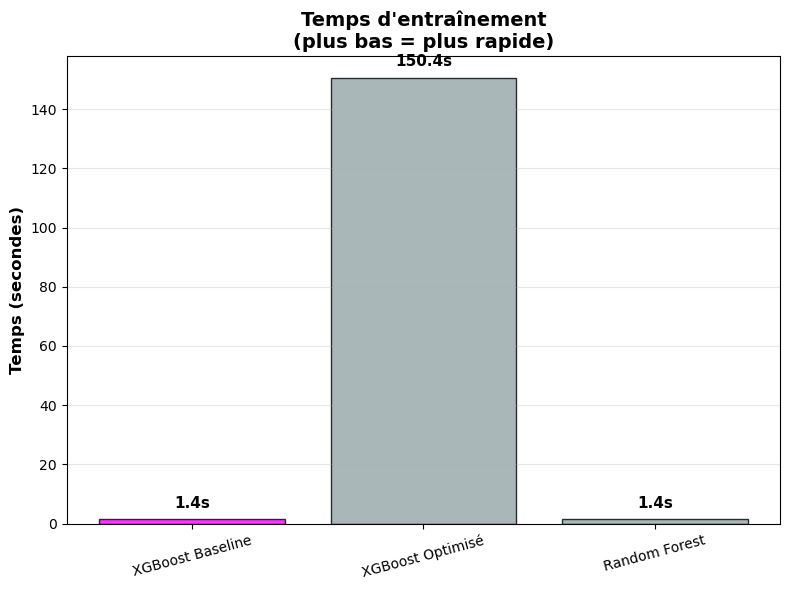

In [ ]:
plt.figure(figsize=(8, 6))

best_idx = comparison_df['Temps (s)'].idxmin()
colors = ["fuchsia" if i == best_idx else '#95a5a6' for i in range(len(comparison_df))]

plt.bar(comparison_df['Modèle'], comparison_df['Temps (s)'], color=colors, edgecolor='black', alpha=0.8)
plt.ylabel('Temps (secondes)', fontsize=12, fontweight='bold')
plt.title('Temps d\'entraînement\n(plus bas = plus rapide)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(comparison_df['Temps (s)']):
    plt.text(i, v + max(comparison_df['Temps (s)'])*0.02, f'{v:.1f}s', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

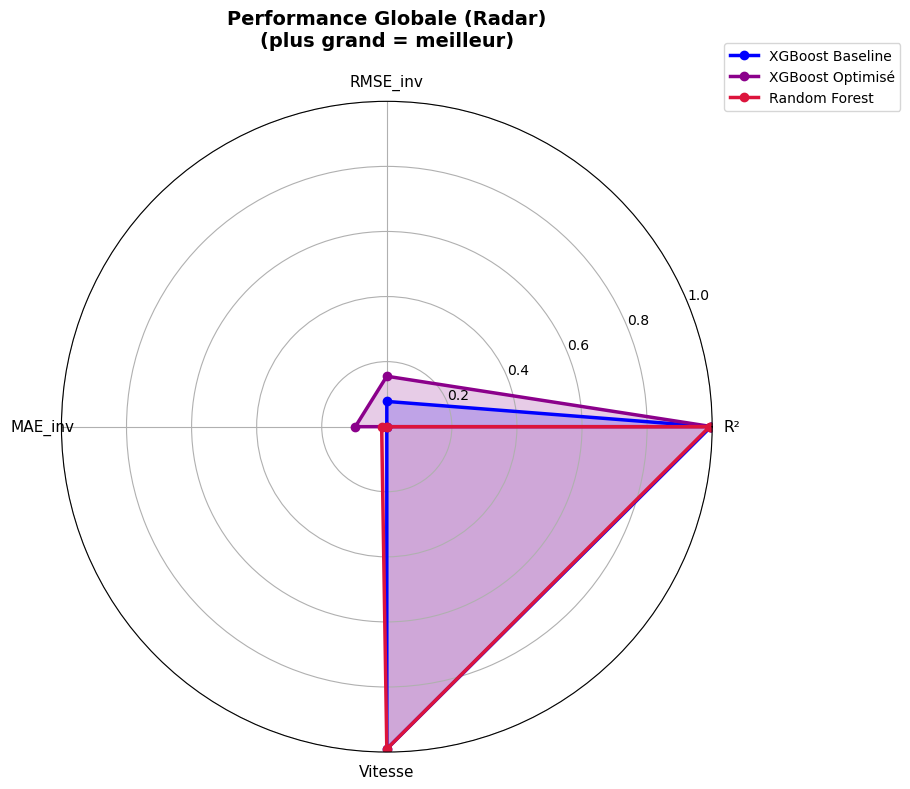

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='polar')

# Définir les métriques
metrics = ['R²', 'RMSE_inv', 'MAE_inv', 'Vitesse']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

# Couleurs pour chaque modèle
colors_models = ["blue", 'darkmagenta', 'crimson']

for idx, row in comparison_df.iterrows():
    # Normaliser les valeurs (1 = meilleur)
    values = [
        row['R²'] / comparison_df['R²'].max(),  # R² : plus grand = meilleur
        1 - (row['RMSE'] / comparison_df['RMSE'].max()),  # RMSE : plus petit = meilleur
        1 - (row['MAE'] / comparison_df['MAE'].max()),  # MAE : plus petit = meilleur
        1 - (row['Temps (s)'] / comparison_df['Temps (s)'].max())  # Temps : plus court = meilleur
    ]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2.5, label=row['Modèle'], color=colors_models[idx])
    ax.fill(angles, values, alpha=0.2, color=colors_models[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Performance Globale (Radar)\n(plus grand = meilleur)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()



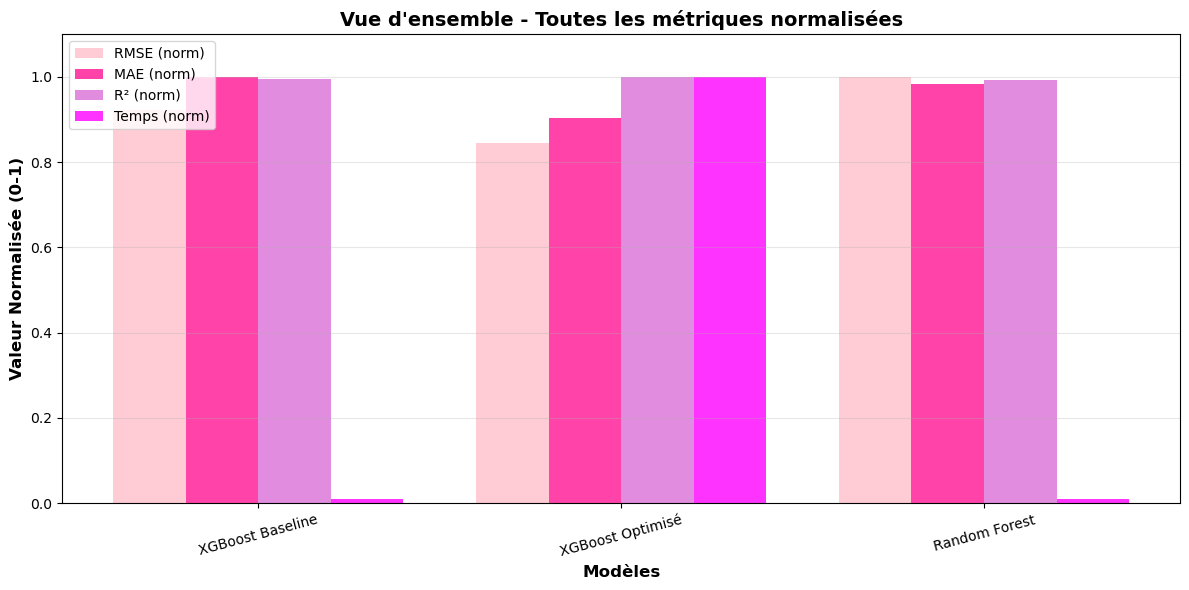

In [ ]:
plt.figure(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.2

rmse_norm = comparison_df['RMSE'] / comparison_df['RMSE'].max()
mae_norm = comparison_df['MAE'] / comparison_df['MAE'].max()
r2_norm = comparison_df['R²'] / comparison_df['R²'].max()
time_norm = comparison_df['Temps (s)'] / comparison_df['Temps (s)'].max()

plt.bar(x - 1.5*width, rmse_norm, width, label='RMSE (norm)', color='pink', alpha=0.8)
plt.bar(x - 0.5*width, mae_norm, width, label='MAE (norm)', color='deeppink', alpha=0.8)
plt.bar(x + 0.5*width, r2_norm, width, label='R² (norm)', color='orchid', alpha=0.8)
plt.bar(x + 1.5*width, time_norm, width, label='Temps (norm)', color='magenta', alpha=0.8)

plt.ylabel('Valeur Normalisée (0-1)', fontsize=12, fontweight='bold')
plt.xlabel('Modèles', fontsize=12, fontweight='bold')
plt.title('Vue d\'ensemble - Toutes les métriques normalisées', fontsize=14, fontweight='bold')
plt.xticks(x, comparison_df['Modèle'], rotation=15)
plt.legend(loc='upper left', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()



In [ ]:
display(comparison_df.style.highlight_max(subset=['R²'], color='violet')
                           .highlight_min(subset=['RMSE', 'MAE', 'Temps (s)'], color='violet')
                           .format({'RMSE': '{:.2f}', 'MAE': '{:.2f}', 'R²': '{:.4f}', 'Temps (s)': '{:.2f}'}))

print("\nMEILLEUR PAR MÉTRIQUE :")
print(f"   - Meilleur R²    : {comparison_df.loc[comparison_df['R²'].idxmax(), 'Modèle']}")
print(f"   - Meilleur RMSE  : {comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Modèle']}")
print(f"   - Meilleur MAE   : {comparison_df.loc[comparison_df['MAE'].idxmin(), 'Modèle']}")
print(f"   - Plus rapide    : {comparison_df.loc[comparison_df['Temps (s)'].idxmin(), 'Modèle']}")

best_model = comparison_df.loc[comparison_df['R²'].idxmax()]
print(f"\nRECOMMANDATION : {best_model['Modèle']}")
print(f"   R² = {best_model['R²']:.4f} | RMSE = {best_model['RMSE']:.2f} | MAE = {best_model['MAE']:.2f}")



,Modèle,RMSE,MAE,R²,Temps (s)
0,XGBoost Baseline,299.66,188.26,0.9772,1.43
1,XGBoost Optimisé,274.51,170.04,0.9809,150.44
2,Random Forest,324.90,185.28,0.9732,1.43



MEILLEUR PAR MÉTRIQUE :
   - Meilleur R²    : XGBoost Optimisé
   - Meilleur RMSE  : XGBoost Optimisé
   - Meilleur MAE   : XGBoost Optimisé
   - Plus rapide    : XGBoost Baseline

RECOMMANDATION : XGBoost Optimisé
   R² = 0.9809 | RMSE = 274.51 | MAE = 170.04


In [ ]:
features_baseline = pd.DataFrame(results_baseline['feature_importance']).nlargest(3, 'Importance')
print("XGBoost Baseline :")
for idx, row in features_baseline.iterrows():
    print(f"   {idx+1}. {row['Feature']:30s} ({row['Importance']:.4f})")
print()

features_optimized = pd.DataFrame(results_optimized['feature_importance']).nlargest(3, 'Importance')
print("XGBoost Optimisé :")
for idx, row in features_optimized.iterrows():
    print(f"   {idx+1}. {row['Feature']:30s} ({row['Importance']:.4f})")
print()

features_rf = pd.DataFrame(results_rf['feature_importance']).nlargest(3, 'Importance')
print("Random Forest :")
for idx, row in features_rf.iterrows():
    print(f"   {idx+1}. {row['Feature']:30s} ({row['Importance']:.4f})")

XGBoost Baseline :
   75. time_of_day_Nuit               (0.8997)
   8. hour                           (0.0232)
   9. day_of_week                    (0.0167)

XGBoost Optimisé :
   75. time_of_day_Nuit               (0.9095)
   8. hour                           (0.0174)
   13. is_holiday                     (0.0169)

Random Forest :
   75. time_of_day_Nuit               (0.8997)
   8. hour                           (0.0232)
   9. day_of_week                    (0.0167)


In [ ]:
baseline_rmse = results_baseline['rmse']
baseline_mae = results_baseline['mae']
baseline_r2 = results_baseline['r2']

print(f"BASELINE : RMSE={baseline_rmse:.2f} | MAE={baseline_mae:.2f} | R²={baseline_r2:.4f}")
print()

for idx, row in comparison_df.iterrows():
    if row['Modèle'] != 'XGBoost Baseline':
        rmse_improvement = ((baseline_rmse - row['RMSE']) / baseline_rmse) * 100
        mae_improvement = ((baseline_mae - row['MAE']) / baseline_mae) * 100
        r2_improvement = ((row['R²'] - baseline_r2) / baseline_r2) * 100
        
        print(f"{row['Modèle']} :")
        print(f"   RMSE : {rmse_improvement:+.2f}% {'(amélioration)' if rmse_improvement > 0 else '(dégradation)'}")
        print(f"   MAE  : {mae_improvement:+.2f}% {'(amélioration)' if mae_improvement > 0 else '(dégradation)'}")
        print(f"   R²   : {r2_improvement:+.2f}% {'(amélioration)' if r2_improvement > 0 else '(dégradation)'}")
        print()

BASELINE : RMSE=299.66 | MAE=188.26 | R²=0.9772

XGBoost Optimisé :
   RMSE : +8.39% (amélioration)
   MAE  : +9.68% (amélioration)
   R²   : +0.38% (amélioration)

Random Forest :
   RMSE : -8.42% (dégradation)
   MAE  : +1.58% (amélioration)
   R²   : -0.41% (dégradation)

